In [98]:
import pandas as pd 
import numpy as np 
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [99]:
data = pd.read_csv(Path(Path().cwd(), "models/2025-11-12 CD19-CD20 Platform Fit Model/AR25-094 Model Data.csv"))
data = data.dropna(how='all')
data

,Asset Name,Experiment,Batch,Sample_Time,Day,TCC,VCC,Viability,Diameter,Osmolality,...,pH at Temp,IGG,DO,pH_setpoint,pH_setpoint_low,pH_setpoint_high,Temperature_setpoint,Daily_Feed,Normalized_Daily_Feed,Volume
0,CD19/CD20,AR25-094,AR25-094-024,10/22/2025 13:15,0.0,18.0433,17.8997,99.2,14.54,302.0,...,7.21,128.4369,50.0,7.1,7.0,7.2,35.0,0.00,0.000000,198.16
1,CD19/CD20,AR25-094,AR25-094-024,10/23/2025 9:37,1.0,27.4302,27.0771,98.7,13.85,264.0,...,7.22,NaN,50.0,7.1,7.0,7.2,35.0,1.28,0.006471,197.81
2,CD19/CD20,AR25-094,AR25-094-024,10/24/2025 9:36,2.0,34.0294,33.3080,97.9,13.64,268.0,...,7.26,1262.1560,50.0,7.1,7.0,7.2,35.0,2.23,0.011257,198.10
3,CD19/CD20,AR25-094,AR25-094-024,10/25/2025 9:36,3.0,46.7339,45.5173,97.4,13.88,274.0,...,7.20,NaN,50.0,7.1,7.0,7.2,35.0,2.79,0.014131,197.44
4,CD19/CD20,AR25-094,AR25-094-024,10/26/2025 9:35,4.0,31.6069,29.9955,94.9,13.99,282.0,...,7.15,1428.1650,50.0,7.1,7.0,7.2,35.0,3.56,0.018027,197.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146,CD19/CD20,AR25-094,AR25-094-013,10/30/2025 8:36,8.0,32.0591,25.5633,79.7,15.04,333.0,...,7.08,NaN,50.0,6.9,6.8,7.0,35.0,2.74,0.014121,194.04
147,CD19/CD20,AR25-094,AR25-094-013,10/31/2025 8:36,9.0,33.3188,25.3918,76.2,14.71,343.0,...,7.07,3736.0200,50.0,6.9,6.8,7.0,35.0,2.79,0.014422,193.45
148,CD19/CD20,AR25-094,AR25-094-013,11/1/2025 8:30,10.0,36.1684,26.6902,73.8,14.78,356.0,...,7.07,NaN,50.0,6.9,6.8,7.0,35.0,2.80,0.014515,192.91
149,CD19/CD20,AR25-094,AR25-094-013,11/2/2025 8:36,11.0,32.5149,22.3872,68.9,14.43,382.0,...,6.96,4007.1150,50.0,6.9,6.8,7.0,35.0,3.03,0.015612,194.08


In [100]:
discard_batches = []

training_columns = [
    "Day",
    "Batch",
    # "TCC",
    "VCC",
    "Viability",
    # "Diameter",
    "Osmolality",
    "Ammonium",
    # "Calcium",
    "Glucose",
    # "Glutamine",
    "Glutamate",
    "Lactate",
    # "Potassium",
    # "Sodium",
    # "Bicarbonate",
    "pCO2 at Temp",
    "pO2 at Temp",
    "pH at Temp",
    "IGG",
]

In [101]:
# batch_mask = data["Batch"].isin(list(set(data["Batch"]) - set(discard_batches)))
regression_data = data.loc[:, training_columns]
grouped = regression_data.groupby("Batch", group_keys=False, as_index=False)
df_interpolate = grouped.apply(
    lambda group: group.interpolate(method="linear", limit_direction="forward")
)

training_columns.remove("Day")
training_columns.remove("Batch")
X = df_interpolate.loc[regression_data["Day"]!=12, training_columns]
y = df_interpolate.loc[regression_data["Day"]!=0, "IGG"]
X_train, X_test, y_train, y_test = train_test_split(X.iloc[:-1], y, test_size=0.2, random_state=42)

C:\Users\zah48132\AppData\Local\Temp\ipykernel_3456\163988556.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda group: group.interpolate(method="linear", limit_direction="forward")
C:\Users\zah48132\AppData\Local\Temp\ipykernel_3456\163988556.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda group: group.interpolate(method="linear", limit_direction="forward")
C:\Users\zah48132\AppData\Local\Temp\ipykernel_3456\163988556.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  lambda group: group.interpolate(method="linear", limit_direction="forward")
C:\Users\zah48132\AppData\Local\Temp\ipykernel_3456\

In [102]:
pipeline_ = Pipeline(
    [("scaler", MinMaxScaler()), ("rfe", RFE(estimator=LinearRegression(), n_features_to_select=5, step=1))]
)

In [103]:
pipeline_.fit(X=X_train, y=y_train)

best_features = []
for label, rank in zip(training_columns, pipeline_.named_steps["rfe"].ranking_):
    if rank == 1:
        best_features.append(label)

for label, coef in zip(best_features, pipeline_.named_steps["rfe"].estimator_.coef_):
    print(f"{label:<15}: {coef: .2f}")

VCC            : -1213.95
Viability      :  3059.75
Osmolality     :  36.75
Lactate        : -3030.67
IGG            :  5629.27


Text(0.5, 1.0, 'R2:  0.147')

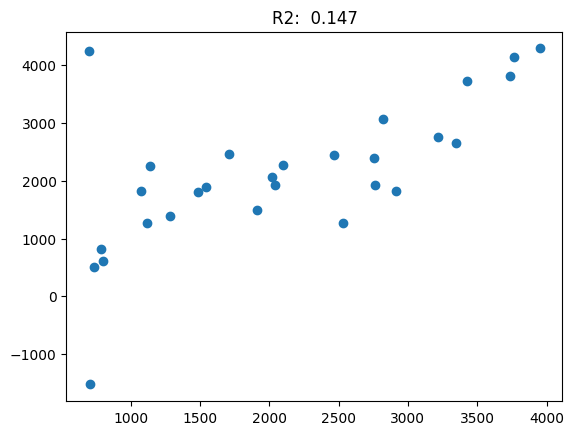

In [104]:
predictions = pipeline_.predict(X_test)
plt.scatter(y_test, predictions)
score_ = r2_score(y_test, predictions)
plt.title(f"R2: {score_: 0.3f}")